# RQ3: Explanation Stability

Kaggle-ready notebook. It auto-detects `AirQualityUCI.csv` and `energydata_complete.csv` / `KAG_energydata_complete.csv`, then saves result tables as CSV and figures as PDF in `/kaggle/working/`.


Air Quality path: /kaggle/input/datasets/primnatoms/airqualityuci/AirQualityUCI.csv
Energy path: /kaggle/input/datasets/primnatoms/energydata-complete/KAG_energydata_complete.csv

Dataset: Air Quality, Target: CO(GT), Shape: (3993, 96)

Dataset: Appliances Energy, Target: Appliances, Shape: (3993, 224)


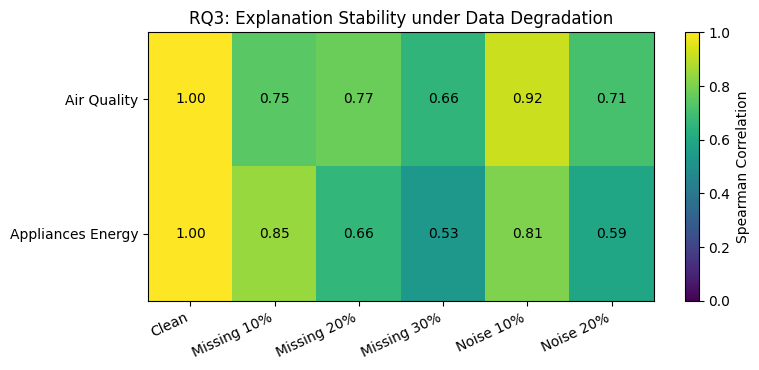

,Dataset,Target,Scenario,Spearman Correlation vs Clean
0,Air Quality,CO(GT),Clean,1.000000
1,Air Quality,CO(GT),Missing 10%,0.745347
2,Air Quality,CO(GT),Missing 20%,0.774186
3,Air Quality,CO(GT),Missing 30%,0.655060
4,Air Quality,CO(GT),Noise 10%,0.920605
5,Air Quality,CO(GT),Noise 20%,0.707230
6,Appliances Energy,Appliances,Clean,1.000000
7,Appliances Energy,Appliances,Missing 10%,0.846202
8,Appliances Energy,Appliances,Missing 20%,0.663770
9,Appliances Energy,Appliances,Missing 30%,0.533770


Saved table: /kaggle/working/rq3_explanation_stability_outputs/Table3_RQ3_explanation_stability.csv
Saved figure: /kaggle/working/rq3_explanation_stability_outputs/Figure3_RQ3_explanation_stability_heatmap.pdf


In [1]:

# ============================================================
# Common setup for robust AI experiments on Kaggle
# Datasets:
# 1) AirQualityUCI.csv
# 2) energydata_complete.csv / KAG_energydata_complete.csv
# ============================================================

import os, glob, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, ks_2samp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def find_file(possible_names):
    if isinstance(possible_names, str):
        possible_names = [possible_names]
    for filename in possible_names:
        matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    for filename in possible_names:
        local = f"/mnt/data/{filename}"
        if os.path.exists(local):
            return local
    print("Available files:")
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

AIR_PATH = find_file(["AirQualityUCI.csv", "AirQualityUCI(2).csv"])
ENERGY_PATH = find_file(["energydata_complete.csv", "KAG_energydata_complete.csv"])

print("Air Quality path:", AIR_PATH)
print("Energy path:", ENERGY_PATH)

def ensure_output_dir(name):
    out = f"/kaggle/working/{name}"
    if not os.path.exists("/kaggle/working"):
        out = f"./{name}"
    os.makedirs(out, exist_ok=True)
    return out

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def load_air_quality(path=AIR_PATH):
    df = pd.read_csv(path, sep=None, engine="python")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "Date" in df.columns and "Time" in df.columns:
        df["datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce", dayfirst=True)
        df = df.sort_values("datetime").drop(columns=["Date", "Time"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df = df.replace(-200, np.nan)
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.dropna(axis=1, thresh=max(1, int(0.6 * len(numeric))))
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def load_energy(path=ENERGY_PATH):
    df = pd.read_csv(path)
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.sort_values("date").drop(columns=["date"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.replace([np.inf, -np.inf], np.nan)
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def make_supervised(df, target=None, lag=3, max_rows=6000):
    df = df.copy()
    if len(df) > max_rows:
        df = df.iloc[:max_rows].copy()
    if target is None:
        target = df.columns[0]
    for l in range(1, lag + 1):
        for c in df.columns:
            df[f"{c}_lag{l}"] = df[c].shift(l)
    df["target_next"] = df[target].shift(-1)
    df = df.dropna()
    X = df.drop(columns=["target_next"])
    y = df["target_next"]
    return X, y, target

def prepare_datasets(max_rows=6000, lag=3):
    air = load_air_quality()
    energy = load_energy()
    air_target = next((c for c in ["CO(GT)", "NO2(GT)", "C6H6(GT)", "T"] if c in air.columns), air.columns[0])
    energy_target = "Appliances" if "Appliances" in energy.columns else energy.columns[0]
    X_air, y_air, t_air = make_supervised(air, target=air_target, lag=lag, max_rows=max_rows)
    X_energy, y_energy, t_energy = make_supervised(energy, target=energy_target, lag=lag, max_rows=max_rows)
    return {"Air Quality": (X_air, y_air, t_air), "Appliances Energy": (X_energy, y_energy, t_energy)}

def train_test_time_split(X, y, train_frac=0.7):
    split = int(len(X) * train_frac)
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

def build_models():
    return {
        "Random Forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]),
        "HistGradientBoosting": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE))]),
        "MLP": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE))])
    }

def corrupt_missing(X, rate):
    Xc = X.copy()
    if rate <= 0:
        return Xc
    rng = np.random.default_rng(RANDOM_STATE + int(rate * 1000))
    mask = rng.random(Xc.shape) < rate
    return Xc.mask(mask)

def corrupt_noise(X, noise_level):
    Xc = X.copy()
    if noise_level <= 0:
        return Xc
    std = Xc.std(numeric_only=True).replace(0, 1).values
    rng = np.random.default_rng(RANDOM_STATE + int(noise_level * 1000))
    noise = rng.normal(0, noise_level, size=Xc.shape) * std
    return Xc + noise

def evaluate_regression(y_true, pred):
    return {"RMSE": rmse(y_true, pred), "MAE": float(mean_absolute_error(y_true, pred)), "R2": float(r2_score(y_true, pred))}

# ============================================================
# RQ3: Explainability Stability using permutation importance
# ============================================================
OUT = ensure_output_dir("rq3_explanation_stability_outputs")
datasets = prepare_datasets(max_rows=4000, lag=3)
scenarios = [("Clean", "clean", 0.0), ("Missing 10%", "missing", 0.10), ("Missing 20%", "missing", 0.20), ("Missing 30%", "missing", 0.30), ("Noise 10%", "noise", 0.10), ("Noise 20%", "noise", 0.20)]
rows = []
for dataset_name, (X, y, target) in datasets.items():
    print(f"\nDataset: {dataset_name}, Target: {target}, Shape: {X.shape}")
    X_train, X_test, y_train, y_test = train_test_time_split(X, y)
    model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1))])
    model.fit(X_train, y_train)
    X_eval_base = X_test.iloc[:min(600, len(X_test))].copy()
    y_eval_base = y_test.iloc[:min(600, len(y_test))].copy()
    base_importance = permutation_importance(model, X_eval_base, y_eval_base, n_repeats=5, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error").importances_mean
    clean_rank = np.argsort(np.argsort(-np.abs(base_importance)))
    for scenario_name, scenario_type, value in scenarios:
        if scenario_type == "clean":
            X_eval = X_eval_base.copy()
        elif scenario_type == "missing":
            X_eval = corrupt_missing(X_eval_base, value)
        else:
            X_eval = corrupt_noise(X_eval_base, value)
        imp = permutation_importance(model, X_eval, y_eval_base, n_repeats=5, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error").importances_mean
        rank = np.argsort(np.argsort(-np.abs(imp)))
        corr = 1.0 if scenario_type == "clean" else spearmanr(clean_rank, rank).correlation
        if np.isnan(corr):
            corr = 0.0
        rows.append({"Dataset": dataset_name, "Target": target, "Scenario": scenario_name, "Spearman Correlation vs Clean": corr})
table = pd.DataFrame(rows)
table_path = f"{OUT}/Table3_RQ3_explanation_stability.csv"
table.to_csv(table_path, index=False)
pivot = table.pivot(index="Dataset", columns="Scenario", values="Spearman Correlation vs Clean")
ordered_cols = [s[0] for s in scenarios]
pivot = pivot[ordered_cols]
plt.figure(figsize=(8, 3.8))
im = plt.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, label="Spearman Correlation")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("RQ3: Explanation Stability under Data Degradation")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")
plt.tight_layout()
fig_path = f"{OUT}/Figure3_RQ3_explanation_stability_heatmap.pdf"
plt.savefig(fig_path)
plt.show()
display(table)
print("Saved table:", table_path)
print("Saved figure:", fig_path)
